In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import numpy as np
import pandas as pd
import random
import torch


def set_seed(seed: int = 42) -> None:
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    # When running on the CuDNN backend, two further options must be set
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    # Set a fixed value for the hash seed
    os.environ["PYTHONHASHSEED"] = str(seed)
    print(f"Random seed set as {seed}")


set_seed()

Random seed set as 42


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils
import torch.distributions
import torchvision
import numpy as np
import matplotlib.pyplot as plt; plt.rcParams['figure.dpi'] = 140


from tqdm.notebook import tqdm
from torchvision import transforms
from torchvision.utils import make_grid
from torchvision.transforms import ToPILImage
from scipy.stats import norm

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

## DDPM

In [ ]:
class DiffusionForwardProcess:

    r"""

    Forward Process class as described in the
    paper "Denoising Diffusion Probabilistic Models"

    """

    def __init__(self,
                 num_time_steps = 1000,
                 beta_start = 1e-4,
                 beta_end = 0.02
                ):

        # Precomputing beta, alpha, and alpha_bar for all t's.
        self.betas = torch.linspace(beta_start, beta_end, num_time_steps)
        self.alphas = 1 - self.betas
        self.alpha_bars = torch.cumprod(self.alphas, dim=0)
        self.sqrt_alpha_bars = torch.sqrt(self.alpha_bars)
        self.sqrt_one_minus_alpha_bars = torch.sqrt(1 - self.alpha_bars)

    def add_noise(self, original, noise, t):

        r""" Adds noise to a batch of original images at time-step t.

        :param original: Input Image Tensor
        :param noise: Random Noise Tensor sampled from Normal Dist N(0, 1)
        :param t: timestep of the forward process of shape -> (B, )

        Note: time-step t may differ for each image inside the batch.

        """

        sqrt_alpha_bar_t = self.sqrt_alpha_bars.to(original.device)[t]
        sqrt_one_minus_alpha_bar_t = self.sqrt_one_minus_alpha_bars.to(original.device)[t]

        # Broadcast to multiply with the original image.
        sqrt_alpha_bar_t = sqrt_alpha_bar_t[:, None, None, None]
        sqrt_one_minus_alpha_bar_t = sqrt_one_minus_alpha_bar_t[:, None, None, None]

        # Return
        return (sqrt_alpha_bar_t * original) \
                           + \
               (sqrt_one_minus_alpha_bar_t * noise)


class DiffusionReverseProcess:

    r"""

    Reverse Process class as described in the
    paper "Denoising Diffusion Probabilistic Models"

    """

    def __init__(self,
                 num_time_steps = 1000,
                 beta_start = 1e-4,
                 beta_end = 0.02
                ):

        # Precomputing beta, alpha, and alpha_bar for all t's.
        self.b = torch.linspace(beta_start, beta_end, num_time_steps) # b -> beta
        self.a = 1 - self.b # a -> alpha
        self.a_bar = torch.cumprod(self.a, dim=0) # a_bar = alpha_bar

    def sample_prev_timestep(self, xt, noise_pred, t):

        r""" Sample x_(t-1) given x_t and noise predicted
             by model.

             :param xt: Image tensor at timestep t of shape -> B x C x H x W
             :param noise_pred: Noise Predicted by model of shape -> B x C x H x W
             :param t: Current time step

        """

        # Original Image Prediction at timestep t
        x0 = xt - (torch.sqrt(1 - self.a_bar.to(xt.device)[t]) * noise_pred)
        x0 = x0/torch.sqrt(self.a_bar.to(xt.device)[t])
        x0 = torch.clamp(x0, -1., 1.)

        # mean of x_(t-1)
        mean = (xt - ((1 - self.a.to(xt.device)[t]) * noise_pred)/(torch.sqrt(1 - self.a_bar.to(xt.device)[t])))
        mean = mean/(torch.sqrt(self.a.to(xt.device)[t]))

        # only return mean
        if t == 0:
            return mean, x0

        else:
            variance =  (1 - self.a_bar.to(xt.device)[t-1])/(1 - self.a_bar.to(xt.device)[t])
            variance = variance * self.b.to(xt.device)[t]
            sigma = variance**0.5
            z = torch.randn(xt.shape).to(xt.device)

            return mean + sigma * z, x0


def get_time_embedding(
    time_steps: torch.Tensor,
    t_emb_dim: int
) -> torch.Tensor:

    """
    Transform a scalar time-step into a vector representation of size t_emb_dim.

    :param time_steps: 1D tensor of size -> (Batch,)
    :param t_emb_dim: Embedding Dimension -> for ex: 128 (scalar value)

    :return tensor of size -> (B, t_emb_dim)
    """

    assert t_emb_dim%2 == 0, "time embedding must be divisible by 2."

    factor = 2 * torch.arange(start = 0,
                              end = t_emb_dim//2,
                              dtype=torch.float32,
                              device=time_steps.device
                             ) / (t_emb_dim)

    factor = 10000**factor

    t_emb = time_steps[:,None] # B -> (B, 1)
    t_emb = t_emb/factor # (B, 1) -> (B, t_emb_dim//2)
    t_emb = torch.cat([torch.sin(t_emb), torch.cos(t_emb)], dim=1) # (B , t_emb_dim)

    return t_emb


class NormActConv(nn.Module):
    """
    Perform GroupNorm, Activation, and Convolution operations.
    """
    def __init__(self,
                 in_channels:int,
                 out_channels:int,
                 num_groups:int = 8,
                 kernel_size: int = 3,
                 norm:bool = True,
                 act:bool = True
                ):
        super(NormActConv, self).__init__()

        # GroupNorm
        self.g_norm = nn.GroupNorm(
            num_groups,
            in_channels
        ) if norm is True else nn.Identity()

        # Activation
        self.act = nn.SiLU() if act is True else nn.Identity()

        # Convolution
        self.conv = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size,
            padding=(kernel_size - 1)//2
        )

    def forward(self, x):
        x = self.g_norm(x)
        x = self.act(x)
        x = self.conv(x)
        return x

#-----------------------------------------------------------------

class TimeEmbedding(nn.Module):
    """
    Maps the Time Embedding to the Required output Dimension.
    """
    def __init__(self,
                 n_out:int, # Output Dimension
                 t_emb_dim:int = 128 # Time Embedding Dimension
                ):
        super(TimeEmbedding, self).__init__()

        # Time Embedding Block
        self.te_block = nn.Sequential(
            nn.SiLU(),
            nn.Linear(t_emb_dim, n_out)
        )

    def forward(self, x):
        return self.te_block(x)

#---------------------------------------------------------------

class SelfAttentionBlock(nn.Module):
    """
    Perform GroupNorm and Multiheaded Self Attention operation.
    """
    def __init__(self,
                 num_channels:int,
                 num_groups:int = 8,
                 num_heads:int = 4,
                 norm:bool = True
                ):
        super(SelfAttentionBlock, self).__init__()

        # GroupNorm
        self.g_norm = nn.GroupNorm(
            num_groups,
            num_channels
        ) if norm is True else nn.Identity()

        # Self-Attention
        self.attn = nn.MultiheadAttention(
            num_channels,
            num_heads,
            batch_first=True
        )

    def forward(self, x):
        batch_size, channels, h, w = x.shape
        x = x.reshape(batch_size, channels, h*w)
        x = self.g_norm(x)
        x = x.transpose(1, 2)
        x, _ = self.attn(x, x, x)
        x = x.transpose(1, 2).reshape(batch_size, channels, h, w)
        return x

#----------------------------------------------------------------

class Downsample(nn.Module):
    """
    Perform Downsampling by the factor of k across Height and Width.
    """
    def __init__(self,
                 in_channels:int,
                 out_channels:int,
                 k:int = 2, # Downsampling factor
                 use_conv:bool = True, # If Downsampling using conv-block
                 use_mpool:bool = True # If Downsampling using max-pool
                ):
        super(Downsample, self).__init__()

        self.use_conv = use_conv
        self.use_mpool = use_mpool

        # Downsampling using Convolution
        self.cv = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, kernel_size=1),
            nn.Conv2d(
                in_channels,
                out_channels//2 if use_mpool else out_channels,
                kernel_size=4,
                stride=k,
                padding=1
            )
        ) if use_conv else nn.Identity()

        # Downsampling using Maxpool
        self.mpool = nn.Sequential(
            nn.MaxPool2d(k, k),
            nn.Conv2d(
                in_channels,
                out_channels//2 if use_conv else out_channels,
                kernel_size=1,
                stride=1,
                padding=0
            )
        ) if use_mpool else nn.Identity()

    def forward(self, x):

        if not self.use_conv:
            return self.mpool(x)

        if not self.use_mpool:
            return self.cv(x)

        return torch.cat([self.cv(x), self.mpool(x)], dim=1)

#-----------------------------------------------------------------------

class Upsample(nn.Module):
    """
    Perform Upsampling by the factor of k across Height and Width
    """
    def __init__(self,
                 in_channels:int,
                 out_channels:int,
                 k:int = 2, # Upsampling factor
                 use_conv:bool = True, # Upsampling using conv-block
                 use_upsample:bool = True # Upsampling using nn.upsample
                ):
        super(Upsample, self).__init__()

        self.use_conv = use_conv
        self.use_upsample = use_upsample

        # Upsampling using conv
        self.cv = nn.Sequential(
            nn.ConvTranspose2d(
                in_channels,
                out_channels//2 if use_upsample else out_channels,
                kernel_size=4,
                stride=k,
                padding=1
            ),
            nn.Conv2d(
                out_channels//2 if use_upsample else out_channels,
                out_channels//2 if use_upsample else out_channels,
                kernel_size = 1,
                stride=1,
                padding=0
            )
        ) if use_conv else nn.Identity()

        # Upsamling using nn.Upsample
        self.up = nn.Sequential(
            nn.Upsample(
                scale_factor=k,
                mode = 'bilinear',
                align_corners=False
            ),
            nn.Conv2d(
                in_channels,
                out_channels//2 if use_conv else out_channels,
                kernel_size=1,
                stride=1,
                padding=0
            )
        ) if use_upsample else nn.Identity()

    def forward(self, x):

        if not self.use_conv:
            return self.up(x)

        if not self.use_upsample:
            return self.cv(x)

        return torch.cat([self.cv(x), self.up(x)], dim=1)


class DownC(nn.Module):
    """
    Perform Down-convolution on the input using following approach.
    1. Conv + TimeEmbedding
    2. Conv
    3. Skip-connection from input x.
    4. Self-Attention
    5. Skip-Connection from 3.
    6. Downsampling
    """
    def __init__(self,
                 in_channels:int,
                 out_channels:int,
                 t_emb_dim:int = 128, # Time Embedding Dimension
                 num_layers:int=2,
                 down_sample:bool = True # True for Downsampling
                ):
        super(DownC, self).__init__()

        self.num_layers = num_layers

        self.conv1 = nn.ModuleList([
            NormActConv(in_channels if i==0 else out_channels,
                        out_channels
                       ) for i in range(num_layers)
        ])

        self.conv2 = nn.ModuleList([
            NormActConv(out_channels,
                        out_channels
                       ) for _ in range(num_layers)
        ])

        self.te_block = nn.ModuleList([
            TimeEmbedding(out_channels, t_emb_dim) for _ in range(num_layers)
        ])

        self.attn_block = nn.ModuleList([
            SelfAttentionBlock(out_channels) for _ in range(num_layers)
        ])

        self.down_block =Downsample(out_channels, out_channels) if down_sample else nn.Identity()

        self.res_block = nn.ModuleList([
            nn.Conv2d(
                in_channels if i==0 else out_channels,
                out_channels,
                kernel_size=1
            ) for i in range(num_layers)
        ])

    def forward(self, x, t_emb):

        out = x

        for i in range(self.num_layers):
            resnet_input = out

            # Resnet Block
            out = self.conv1[i](out)
            out = out + self.te_block[i](t_emb)[:, :, None, None]
            out = self.conv2[i](out)
            out = out + self.res_block[i](resnet_input)

            # Self Attention
            out_attn = self.attn_block[i](out)
            out = out + out_attn

        # Downsampling
        out = self.down_block(out)

        return out


class MidC(nn.Module):
    """
    Refine the features obtained from the DownC block.
    It refines the features using following operations:

    1. Resnet Block with Time Embedding
    2. A Series of Self-Attention + Resnet Block with Time-Embedding
    """
    def __init__(self,
                 in_channels:int,
                 out_channels:int,
                 t_emb_dim:int = 128,
                 num_layers:int = 2
                ):
        super(MidC, self).__init__()

        self.num_layers = num_layers

        self.conv1 = nn.ModuleList([
            NormActConv(in_channels if i==0 else out_channels,
                        out_channels
                       ) for i in range(num_layers + 1)
        ])

        self.conv2 = nn.ModuleList([
            NormActConv(out_channels,
                        out_channels
                       ) for _ in range(num_layers + 1)
        ])

        self.te_block = nn.ModuleList([
            TimeEmbedding(out_channels, t_emb_dim) for _ in range(num_layers + 1)
        ])

        self.attn_block = nn.ModuleList([
            SelfAttentionBlock(out_channels) for _ in range(num_layers)
        ])

        self.res_block = nn.ModuleList([
            nn.Conv2d(
                in_channels if i==0 else out_channels,
                out_channels,
                kernel_size=1
            ) for i in range(num_layers + 1)
        ])

    def forward(self, x, t_emb):
        out = x

        # First-Resnet Block
        resnet_input = out
        out = self.conv1[0](out)
        out = out + self.te_block[0](t_emb)[:, :, None, None]
        out = self.conv2[0](out)
        out = out + self.res_block[0](resnet_input)

        # Sequence of Self-Attention + Resnet Blocks
        for i in range(self.num_layers):

            # Self Attention
            out_attn = self.attn_block[i](out)
            out = out + out_attn

            # Resnet Block
            resnet_input = out
            out = self.conv1[i+1](out)
            out = out + self.te_block[i+1](t_emb)[:, :, None, None]
            out = self.conv2[i+1](out)
            out = out + self.res_block[i+1](resnet_input)

        return out


class UpC(nn.Module):
    """
    Perform Up-convolution on the input using following approach.
    1. Upsampling
    2. Conv + TimeEmbedding
    3. Conv
    4. Skip-connection from 1.
    5. Self-Attention
    6. Skip-Connection from 3.
    """
    def __init__(self,
                 in_channels:int,
                 out_channels:int,
                 t_emb_dim:int = 128, # Time Embedding Dimension
                 num_layers:int = 2,
                 up_sample:bool = True # True for Upsampling
                ):
        super(UpC, self).__init__()

        self.num_layers = num_layers

        self.conv1 = nn.ModuleList([
            NormActConv(in_channels if i==0 else out_channels,
                        out_channels
                       ) for i in range(num_layers)
        ])

        self.conv2 = nn.ModuleList([
            NormActConv(out_channels,
                        out_channels
                       ) for _ in range(num_layers)
        ])

        self.te_block = nn.ModuleList([
            TimeEmbedding(out_channels, t_emb_dim) for _ in range(num_layers)
        ])

        self.attn_block = nn.ModuleList([
            SelfAttentionBlock(out_channels) for _ in range(num_layers)
        ])

        self.up_block =Upsample(in_channels, in_channels//2) if up_sample else nn.Identity()

        self.res_block = nn.ModuleList([
            nn.Conv2d(
                in_channels if i==0 else out_channels,
                out_channels,
                kernel_size=1
            ) for i in range(num_layers)
        ])

    def forward(self, x, down_out, t_emb):

        # Upsampling
        x = self.up_block(x)
        x = torch.cat([x, down_out], dim=1)

        out = x
        for i in range(self.num_layers):
            resnet_input = out

            # Resnet Block
            out = self.conv1[i](out)
            out = out + self.te_block[i](t_emb)[:, :, None, None]
            out = self.conv2[i](out)
            out = out + self.res_block[i](resnet_input)

            # Self Attention
            out_attn = self.attn_block[i](out)
            out = out + out_attn

        return out


class Unet(nn.Module):
    """
    U-net architecture which is used to predict noise
    in the paper "Denoising Diffusion Probabilistic Model".

    U-net consists of Series of DownC blocks followed by MidC
    followed by UpC.
    """

    def __init__(self,
                 im_channels: int = 1, # RGB
                 down_ch: list = [32, 64, 128, 256],
                 mid_ch: list = [256, 256, 128],
                 up_ch: list[int] = [256, 128, 64, 16],
                 down_sample: list[bool] = [True, True, False],
                 t_emb_dim: int = 128,
                 num_downc_layers:int = 2,
                 num_midc_layers:int = 2,
                 num_upc_layers:int = 2
                ):
        super(Unet, self).__init__()

        self.im_channels = im_channels
        self.down_ch = down_ch
        self.mid_ch = mid_ch
        self.up_ch = up_ch
        self.t_emb_dim = t_emb_dim
        self.down_sample = down_sample
        self.num_downc_layers = num_downc_layers
        self.num_midc_layers = num_midc_layers
        self.num_upc_layers = num_upc_layers

        self.up_sample = list(reversed(self.down_sample)) # [False, True, True]

        # Initial Convolution
        self.cv1 = nn.Conv2d(self.im_channels, self.down_ch[0], kernel_size=3, padding=1)

        # Initial Time Embedding Projection
        self.t_proj = nn.Sequential(
            nn.Linear(self.t_emb_dim, self.t_emb_dim),
            nn.SiLU(),
            nn.Linear(self.t_emb_dim, self.t_emb_dim)
        )

        # DownC Blocks
        self.downs = nn.ModuleList([
            DownC(
                self.down_ch[i],
                self.down_ch[i+1],
                self.t_emb_dim,
                self.num_downc_layers,
                self.down_sample[i]
            ) for i in range(len(self.down_ch) - 1)
        ])

        # MidC Block
        self.mids = nn.ModuleList([
            MidC(
                self.mid_ch[i],
                self.mid_ch[i+1],
                self.t_emb_dim,
                self.num_midc_layers
            ) for i in range(len(self.mid_ch) - 1)
        ])

        # UpC Block
        self.ups = nn.ModuleList([
            UpC(
                self.up_ch[i],
                self.up_ch[i+1],
                self.t_emb_dim,
                self.num_upc_layers,
                self.up_sample[i]
            ) for i in range(len(self.up_ch) - 1)
        ])

        # Final Convolution
        self.cv2 = nn.Sequential(
            nn.GroupNorm(8, self.up_ch[-1]),
            nn.Conv2d(self.up_ch[-1], self.im_channels, kernel_size=3, padding=1)
        )

    def forward(self, x, t):

        out = self.cv1(x)

        # Time Projection
        t_emb = get_time_embedding(t, self.t_emb_dim)
        t_emb = self.t_proj(t_emb)

        # DownC outputs
        down_outs = []

        for down in self.downs:
            down_outs.append(out)
            out = down(out, t_emb)

        # MidC outputs
        for mid in self.mids:
            out = mid(out, t_emb)

        # UpC Blocks
        for up in self.ups:
            down_out = down_outs.pop()
            out = up(out, down_out, t_emb)

        # Final Conv
        out = self.cv2(out)

        return out

## DDIM

In [ ]:
class DDIM:
    def __init__(self, T, model, device):
        self.T = T
        self.function_approximator = model.to(device)
        self.device = device

        self.beta = torch.linspace(1e-4, 0.02, T).to(device)
        self.alpha = 1. - self.beta
        self.alpha_bar = torch.cumprod(self.alpha, dim=0)

    @torch.no_grad()
    def sampling(self, n_samples=1, image_channels=1, img_size=(28, 28),
                      n_steps=50, use_tqdm=True, initial_noise=None):

        step_size = self.T // n_steps
        if initial_noise is None:
            x = torch.randn((n_samples, image_channels, img_size[0], img_size[1]),
                        device=self.device)
            noise = x.detach().clone().cpu().numpy()
        else:
            x = torch.from_numpy(initial_noise).to(device)
            noise = None
        progress_bar = tqdm if use_tqdm else lambda x: x

        for i in progress_bar(range(n_steps)):
            t = self.T - i * step_size
            t_tensor = torch.ones(n_samples, dtype=torch.long, device=self.device) * t

            alpha_bar_t = self.alpha_bar[t - 1].unsqueeze(-1).unsqueeze(-1).unsqueeze(-1)
            alpha_bar_prev = self.alpha_bar[t - step_size - 1].unsqueeze(-1).unsqueeze(-1).unsqueeze(-1) if t > step_size else torch.tensor(1.0).to(self.device)

            # Predicted noise
            eps_pred = self.function_approximator(x, t_tensor - 1)

            # Predicted x_0
            x0_pred = (x - torch.sqrt(1 - alpha_bar_t) * eps_pred) / torch.sqrt(alpha_bar_t)

            # Direction pointing to xt
            dir_xt = torch.sqrt(1 - alpha_bar_prev) * eps_pred

            # Update rule
            x = torch.sqrt(alpha_bar_prev) * x0_pred + dir_xt

        x = torch.clamp(x, -1., 1.).detach().cpu().numpy()

        return x, noise

## Generate

Train датасет мниста 42000 картинок, сгенерируем столько же

In [ ]:
model = torch.load('/content/drive/MyDrive/cursach-hse/ddpm_unet.pth', weights_only=False)

ddim = DDIM(1000, model, device)

In [ ]:
generated_imgs = []
noises_unif = []
noises_norm = []

for i in tqdm(range(420)):
    noise_u = np.random.uniform(size=(100, 1, 28, 28))
    noise_n = norm.ppf(noise_u).astype(np.float32)
    x, _ = ddim.sampling(initial_noise=noise_n)
    generated_imgs.append(x)
    noises_unif.append(noise_u)
    noises_norm.append(noise_n)

  0%|          | 0/420 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

...

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

In [ ]:
ddim_imgs = np.vstack(generated_imgs)
ddim_noises_unif = np.vstack(noises_unif)
ddim_noises_norm = np.vstack(noises_norm)

In [ ]:
ddim_imgs.shape, ddim_noises_unif.shape, ddim_noises_norm.shape

((42000, 1, 28, 28), (42000, 1, 28, 28), (42000, 1, 28, 28))

In [ ]:
ddim_imgs = ddim_imgs.reshape(42000, 28*28)
ddim_noises_unif = ddim_noises_unif.reshape(42000, 28*28)
ddim_noises_norm = ddim_noises_norm.reshape(42000, 28*28)

In [ ]:
np.save('/content/ddim_imgs_42000.npy', ddim_imgs)
np.save('/content/ddim_noises_42000_unif.npy', ddim_noises_unif)
np.save('/content/ddim_noises_42000_norm.npy', ddim_noises_norm)

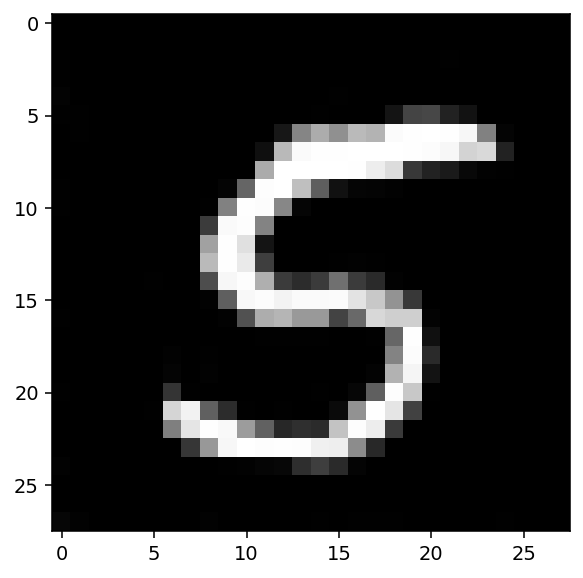

In [ ]:
plt.imshow(ddim_imgs[41000].reshape(28, 28), cmap='gray')